# Modelado Predictivo de Movilidad Urbana en Malta

**Asignatura 7 · Modelado Predictivo con Machine Learning — Máster en Big Data & Business Intelligence**

*Rodrigo Gutiérrez Álvarez · Juan Camilo Henao Barrero · America Nereida Delgado Rodríguez*

Este trabajo aplica las técnicas de Modelado Predictivo con Machine Learning al Trabajo Fin de Máster **"Arquitectura de Big Data para la Captura, Procesamiento y Visualización de Datos de Movilidad Urbana en Tiempo Real"**. El TFM captura, mediante un pipeline propio, datos de tráfico (TomTom y OpenRouteService) y clima (OpenWeatherMap) para 12 corredores urbanos entre 6 zonas de Malta.

El objetivo de este entregable es construir, sobre ese mismo dataset, un sistema de análisis predictivo que aporte valor directo al TFM: anticipar niveles de congestión, estimar tiempos de viaje, proyectar la demanda por franja horaria y segmentar los corredores según su perfil de movilidad.

Se desarrollan cinco componentes, alineados con los criterios de evaluación de la asignatura:

1. **Preprocesamiento** de datos (20%).
2. **Modelos principales**: un modelo de **clasificación** (`mobility_level`) y uno de **regresión** (`travel_time_min`) (70%).
3. **Modelo avanzado/extensión**: un **modelo temporal** de forecasting horario de congestión (5%).
4. **Análisis no supervisado**: **clustering** de corredores urbanos (5%).
5. Interpretación y conclusiones orientadas al TFM.

> **Nota técnica:** este notebook se generó y ejecutó en un entorno Python sin acceso a red, por lo que se usan exclusivamente librerías ya disponibles (`pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`). Donde el equivalente en R usa `xgboost` o `auto.arima` (paquete `forecast`), aquí se sustituyen por `HistGradientBoostingRegressor` (scikit-learn) y un modelo de regresión con variables de rezago, respectivamente — mismo objetivo, implementación equivalente en espíritu.

## Librerías

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import (confusion_matrix, classification_report, f1_score,
                              roc_auc_score, roc_curve, mean_squared_error,
                              mean_absolute_error, r2_score)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
np.random.seed(42)


## Carga de datos

In [2]:

# Ajustar el nombre de archivo si el CSV exportado del pipeline del TFM cambia.
df_raw = pd.read_csv('mobility_data_full_20260830_000146.csv',
                      usecols=lambda c: c != 'polyline')  # polyline: geometria de ruta, no aporta al modelo tabular
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])

print("Shape:", df_raw.shape)
df_raw.head(3)


Shape: (17985, 23)


## Análisis exploratorio de datos (EDA)\n\n### Estructura general y calidad de datos

In [3]:

print("Registros:", len(df_raw), " | Columnas:", df_raw.shape[1])
print()
nulos = df_raw.isnull().sum().sort_values(ascending=False)
print("Nulos por columna (top 10):")
print(nulos.head(10))


Registros: 17985  | Columnas: 23

Nulos por columna (top 10):
traffic_length_km         9741
traffic_delay_min         9741
arrival_time              9741
departure_time            9741
no_traffic_time_min       9741
origin_feels_like           97
destination_feels_like      97
travel_time_min              0
distance_km                  0
data_source                  0
dtype: int64


Los nulos en `no_traffic_time_min`, `traffic_delay_min`, `traffic_length_km`, `departure_time` y `arrival_time` no son errores: corresponden exactamente a los registros capturados por **OpenRouteService (ORS)**, que no calcula tráfico en tiempo real (a diferencia de **TomTom**, que sí).

In [4]:

print(df_raw['data_source'].value_counts())
print()
print(df_raw.groupby('data_source')['traffic_delay_min'].apply(lambda x: x.isnull().sum()))


data_source
ors       9741
tomtom    8244
Name: count, dtype: int64

data_source
ors       9741
tomtom       0
Name: traffic_delay_min, dtype: int64


### Cobertura temporal

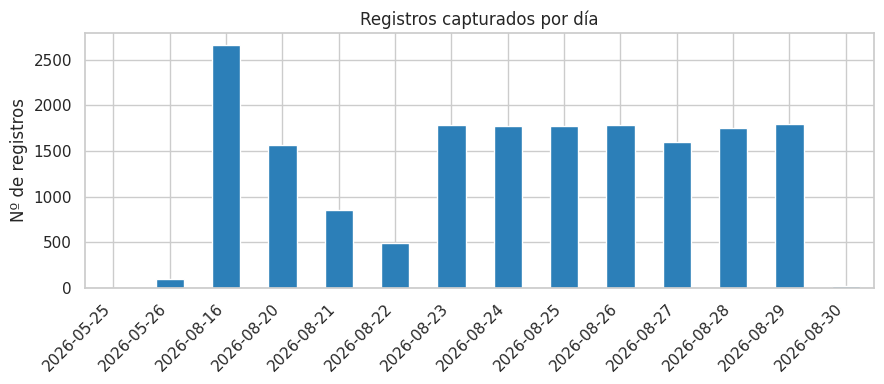

In [5]:

fig, ax = plt.subplots(figsize=(9, 4))
df_raw.assign(fecha=df_raw['timestamp'].dt.date).groupby('fecha').size().plot(kind='bar', ax=ax, color='#2c7fb8')
ax.set_title('Registros capturados por día')
ax.set_xlabel('')
ax.set_ylabel('Nº de registros')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Se observan registros aislados a finales de mayo (pruebas iniciales del pipeline) frente a un bloque denso y continuo entre el 16 y el 30 de agosto de 2026. Se excluyen los registros de mayo del modelado (decisión de calidad de datos, documentada explícitamente):

In [6]:

df = df_raw[df_raw['timestamp'] >= '2026-08-01'].copy()
print("Registros tras excluir el periodo de pruebas de mayo:", len(df))


Registros tras excluir el periodo de pruebas de mayo: 17888


### Variable objetivo de clasificación: `mobility_level`

mobility_level
Movilidad normal    13903
Alta demora          3985
Name: count, dtype: int64
mobility_level
Movilidad normal    77.7
Alta demora         22.3
Name: count, dtype: float64


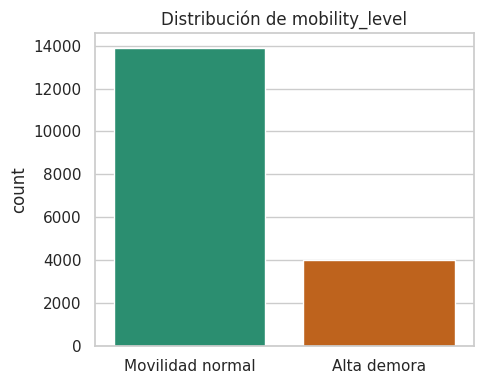

In [7]:

conteo = df['mobility_level'].value_counts()
print(conteo)
print((100 * conteo / conteo.sum()).round(1))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='mobility_level', hue='mobility_level',
              palette={'Alta demora': '#d95f02', 'Movilidad normal': '#1b9e77'}, legend=False, ax=ax)
ax.set_title('Distribución de mobility_level')
ax.set_xlabel('')
plt.tight_layout()
plt.show()


La clase está **desbalanceada** (~78% / ~22%), por lo que en la fase de modelado se usará muestreo estratificado y métricas robustas al desbalance (F1, ROC-AUC), evitando apoyarse solo en accuracy.

### Patrón horario de congestión

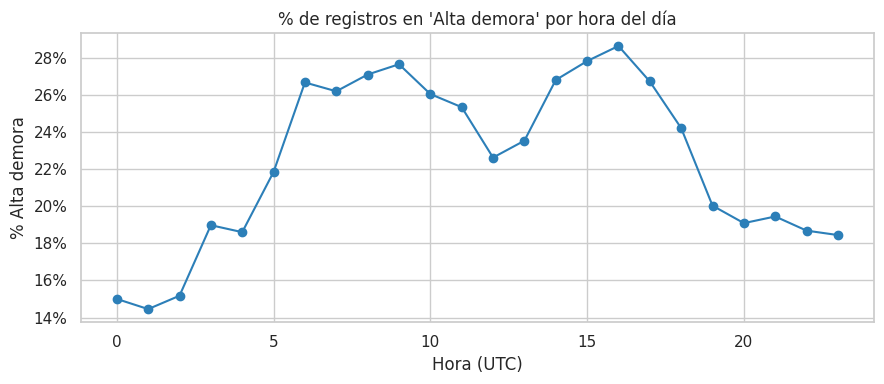

In [8]:

df['hora_tmp'] = df['timestamp'].dt.hour
df['alta_tmp'] = (df['mobility_level'] == 'Alta demora').astype(int)
pct_hora = df.groupby('hora_tmp')['alta_tmp'].mean()

fig, ax = plt.subplots(figsize=(9, 4))
pct_hora.plot(marker='o', color='#2c7fb8', ax=ax)
ax.set_title("% de registros en 'Alta demora' por hora del día")
ax.set_xlabel('Hora (UTC)')
ax.set_ylabel('% Alta demora')
ax.yaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
plt.tight_layout()
plt.show()


Se aprecian dos picos de congestión coherentes con horas punta (mañana ~6-9h y tarde ~14-17h).

### Congestión por corredor (ruta)

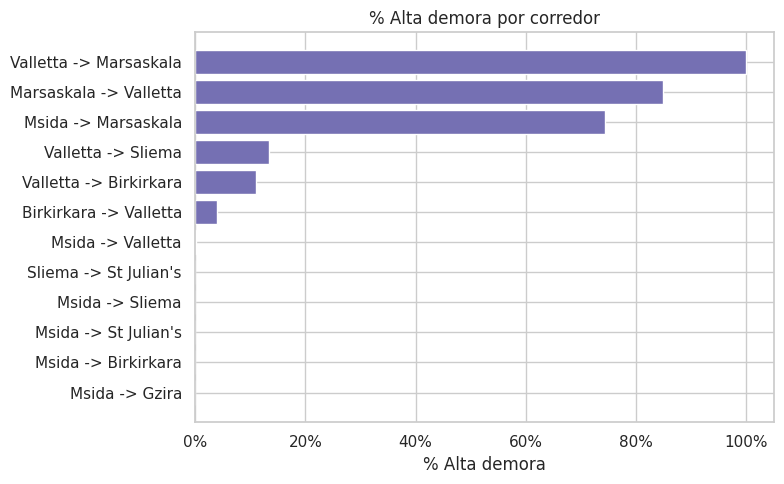

In [9]:

pct_ruta = (df.groupby(['origin', 'destination'])['alta_tmp'].mean()
            .reset_index().assign(ruta=lambda d: d['origin'] + ' -> ' + d['destination'])
            .sort_values('alta_tmp'))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(pct_ruta['ruta'], pct_ruta['alta_tmp'], color='#7570b3')
ax.set_title('% Alta demora por corredor')
ax.set_xlabel('% Alta demora')
ax.xaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
plt.tight_layout()
plt.show()


Los corredores hacia/desde **Marsaskala** concentran, con diferencia, la mayor proporción de alta demora (son también los de mayor distancia).

### Relación entre `mobility_level` y `travel_time_min`

In [10]:

print(df.groupby('mobility_level')['travel_time_min'].agg(['min', 'mean', 'max']))
print()

# Verificacion del umbral: una regla simple sobre travel_time_min reproduce mobility_level?
regla_simple = np.where(df['travel_time_min'] > 20, 'Alta demora', 'Movilidad normal')
print("Exactitud de la regla simple (umbral 20 min):", (regla_simple == df['mobility_level']).mean())


                    min       mean    max
mobility_level                           
Alta demora       20.02  23.914647  45.93
Movilidad normal   3.53   9.276864  20.00

Exactitud de la regla simple (umbral 20 min): 1.0


El resultado es concluyente: `mobility_level` es una **función determinista** de `travel_time_min` con un umbral exacto de 20 minutos (una regla de una sola línea reproduce la etiqueta con exactitud del 100%). No es tráfico observado de forma independiente, sino una **variable derivada** ya en el pipeline del TFM.

**Consecuencia metodológica directa:** `travel_time_min` se **excluye explícitamente** de los predictores del modelo de clasificación, para evitar *data leakage*. El valor real del clasificador está en predecir `mobility_level` **sin conocer aún** el tiempo de viaje real, usando distancia, ruta, hora y clima — el escenario de uso real para el TFM.

### Relación entre variables numéricas y `travel_time_min`

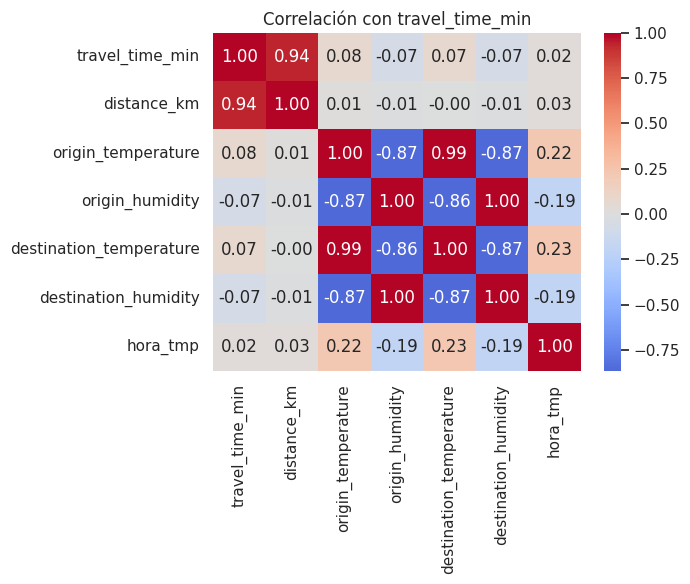

In [11]:

vars_num = ['travel_time_min', 'distance_km', 'origin_temperature', 'origin_humidity',
            'destination_temperature', 'destination_humidity', 'hora_tmp']
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df[vars_num].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlación con travel_time_min')
plt.tight_layout()
plt.show()


`distance_km` es, con mucha diferencia, la variable con mayor correlación con `travel_time_min` (~0.94). Las variables climáticas muestran correlación débil, resultado razonable dado que el clima en el periodo capturado es mayoritariamente estable.

### Condiciones climáticas registradas

In [12]:

conteo_clima = df['origin_weather'].value_counts()
print(conteo_clima)
print((100 * conteo_clima / conteo_clima.sum()).round(1))


origin_weather
clear sky           16867
few clouds            450
scattered clouds      255
broken clouds         149
overcast clouds       147
light rain             20
Name: count, dtype: int64
origin_weather
clear sky           94.3
few clouds           2.5
scattered clouds     1.4
broken clouds        0.8
overcast clouds      0.8
light rain           0.1
Name: count, dtype: float64


## Preprocesamiento de datos\n\n### Ingeniería de variables temporales

In [13]:

df['hora'] = df['timestamp'].dt.hour
df['dia_semana'] = df['timestamp'].dt.dayofweek       # 0 = lunes ... 6 = domingo
df['es_finde'] = df['dia_semana'].isin([5, 6]).astype(int)
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)
print("Variables temporales creadas: hora, dia_semana, es_finde, hora_sin, hora_cos")


Variables temporales creadas: hora, dia_semana, es_finde, hora_sin, hora_cos


Se codifica la hora con transformación seno/coseno para preservar su naturaleza cíclica (23h y 00h están próximas, no en extremos opuestos).

### Selección de variables y tratamiento de fugas de información

In [14]:

# average_speed_kmh se descarta por FUGA DE INFORMACION: es algebraicamente
# equivalente a distance_km / (travel_time_min / 60). Se verifica:
implied_speed = df['distance_km'] / (df['travel_time_min'] / 60)
print("Diferencia media entre average_speed_kmh y la velocidad implicita:",
      round((implied_speed - df['average_speed_kmh']).abs().mean(), 4), "km/h")
print()
print("-> Se excluye average_speed_kmh de los predictores: usarla para predecir")
print("   travel_time_min seria casi circular, y en clasificacion filtraria")
print("   indirectamente el propio travel_time_min (ver umbral determinista).")


Diferencia media entre average_speed_kmh y la velocidad implicita: 0.0177 km/h

-> Se excluye average_speed_kmh de los predictores: usarla para predecir
   travel_time_min seria casi circular, y en clasificacion filtraria
   indirectamente el propio travel_time_min (ver umbral determinista).


In [15]:

def agrupar_clima(x):
    if x == 'clear sky':
        return 'despejado'
    elif x in ['few clouds', 'scattered clouds']:
        return 'parcialmente_nublado'
    elif x in ['broken clouds', 'overcast clouds']:
        return 'nublado'
    else:
        return 'lluvia'

df['origin_weather_grp'] = df['origin_weather'].apply(agrupar_clima)
df['destination_weather_grp'] = df['destination_weather'].apply(agrupar_clima)

cols_modelo = ['origin', 'destination', 'data_source',
               'distance_km',
               'origin_temperature', 'origin_humidity', 'origin_weather_grp',
               'destination_temperature', 'destination_humidity', 'destination_weather_grp',
               'hora_sin', 'hora_cos', 'dia_semana', 'es_finde',
               'travel_time_min', 'mobility_level']

df_model = df[cols_modelo].copy()
print("Nulos en df_model:")
print(df_model.isnull().sum().sum(), "nulos totales")
df_model.head(3)


Nulos en df_model:
0 nulos totales


### Codificación de variables categóricas y escalado

In [16]:

cat_cols = ['origin', 'destination', 'data_source', 'origin_weather_grp', 'destination_weather_grp']
df_enc = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

num_cols = ['distance_km', 'origin_temperature', 'origin_humidity',
            'destination_temperature', 'destination_humidity']

print("Columnas tras one-hot encoding:", df_enc.shape[1])
print("Variables numericas a escalar:", num_cols)


Columnas tras one-hot encoding: 27
Variables numericas a escalar: ['distance_km', 'origin_temperature', 'origin_humidity', 'destination_temperature', 'destination_humidity']


### Partición train/test estratificada

In [17]:

y_clf = (df_enc['mobility_level'] == 'Alta demora').astype(int)

X_cols = [c for c in df_enc.columns if c not in ['mobility_level', 'travel_time_min']]
X_clf = df_enc[X_cols].copy()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

scaler_clf = StandardScaler()
X_train_c[num_cols] = scaler_clf.fit_transform(X_train_c[num_cols])
X_test_c[num_cols] = scaler_clf.transform(X_test_c[num_cols])

print("Train:", X_train_c.shape, " Test:", X_test_c.shape)
print("Balance train:", round(y_train_c.mean(), 3), " | Balance test:", round(y_test_c.mean(), 3))


Train: (14310, 25)  Test: (3578, 25)
Balance train: 0.223  | Balance test: 0.223


## Modelo de clasificación: `mobility_level`

**Justificación del algoritmo:** se comparan dos modelos. Una **regresión logística** como línea base interpretable, y un **Random Forest**, más adecuado por su capacidad de capturar relaciones no lineales e interacciones sin necesidad de especificarlas manualmente, y por ofrecer importancia de variables directamente interpretable para el TFM.

### Línea base: regresión logística

In [18]:

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_c, y_train_c)
pred_log = log_reg.predict(X_test_c)

print(classification_report(y_test_c, pred_log, target_names=['Movilidad normal', 'Alta demora']))


                  precision    recall  f1-score   support

Movilidad normal       0.97      0.98      0.98      2781
     Alta demora       0.94      0.91      0.92       797

        accuracy                           0.97      3578
       macro avg       0.96      0.95      0.95      3578
    weighted avg       0.97      0.97      0.97      3578



### Random Forest con validación cruzada y ajuste de hiperparámetros

In [19]:

param_grid_rf = {'n_estimators': [200], 'max_depth': [None, 10, 20], 'min_samples_leaf': [1, 5]}
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train_c, y_train_c)

print("Mejores hiperparametros:", grid_rf.best_params_)
print("Mejor ROC-AUC (validacion cruzada, 5-fold):", round(grid_rf.best_score_, 4))

best_rf = grid_rf.best_estimator_


Mejores hiperparametros: {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 200}
Mejor ROC-AUC (validacion cruzada, 5-fold): 0.9995


### Evaluación del Random Forest

                  precision    recall  f1-score   support

Movilidad normal       1.00      0.99      0.99      2781
     Alta demora       0.96      0.99      0.98       797

        accuracy                           0.99      3578
       macro avg       0.98      0.99      0.99      3578
    weighted avg       0.99      0.99      0.99      3578

ROC-AUC (test): 0.9996


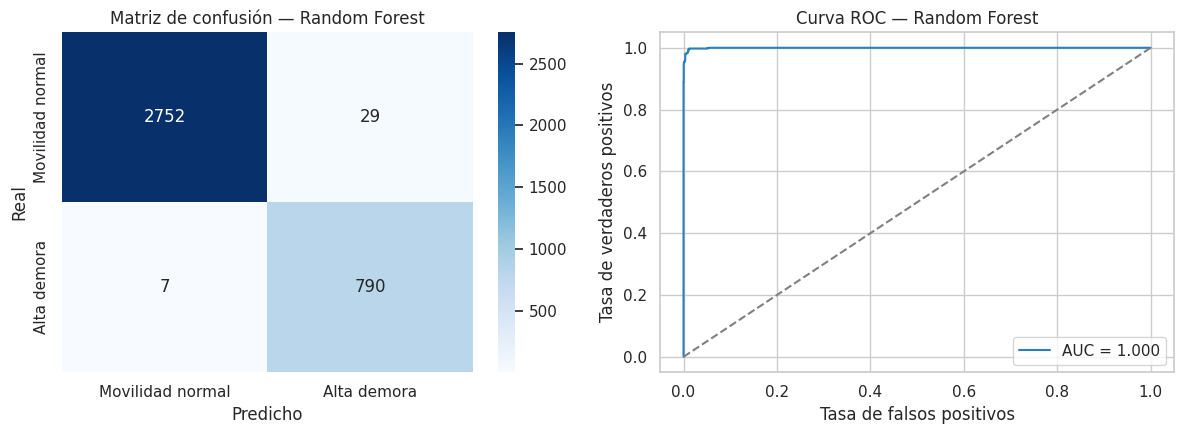

In [20]:

pred_rf = best_rf.predict(X_test_c)
proba_rf = best_rf.predict_proba(X_test_c)[:, 1]

print(classification_report(y_test_c, pred_rf, target_names=['Movilidad normal', 'Alta demora']))
print("ROC-AUC (test):", round(roc_auc_score(y_test_c, proba_rf), 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test_c, pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Movilidad normal', 'Alta demora'],
            yticklabels=['Movilidad normal', 'Alta demora'], ax=axes[0])
axes[0].set_title('Matriz de confusión — Random Forest')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

fpr, tpr, _ = roc_curve(y_test_c, proba_rf)
axes[1].plot(fpr, tpr, color='#2c7fb8', label=f'AUC = {roc_auc_score(y_test_c, proba_rf):.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('Curva ROC — Random Forest')
axes[1].set_xlabel('Tasa de falsos positivos')
axes[1].set_ylabel('Tasa de verdaderos positivos')
axes[1].legend()

plt.tight_layout()
plt.show()


### Importancia de variables

distance_km                0.437309
destination_Marsaskala     0.222538
origin_Marsaskala          0.082083
origin_Msida               0.042473
destination_St Julian's    0.033501
data_source_tomtom         0.026144
origin_Valletta            0.021055
hora_cos                   0.019448
destination_Valletta       0.016257
destination_Sliema         0.015422
dtype: float64


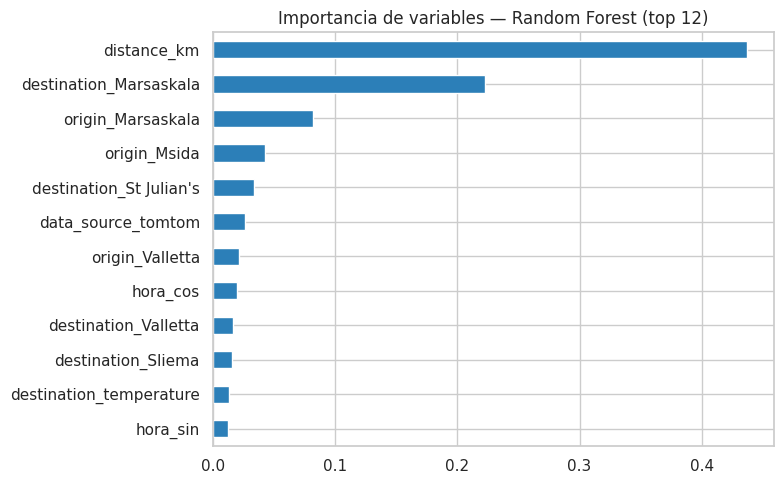

In [21]:

importancias_clf = pd.Series(best_rf.feature_importances_, index=X_train_c.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importancias_clf.head(12).sort_values().plot(kind='barh', color='#2c7fb8', ax=ax)
ax.set_title('Importancia de variables — Random Forest (top 12)')
plt.tight_layout()
plt.show()

print(importancias_clf.head(10))


**Interpretación:** como anticipaba el EDA, `distance_km` y las variables dummy de destino/origen (en particular las asociadas a Marsaskala) dominan la predicción. Esto es consistente con la propia definición de `mobility_level` en el pipeline del TFM (umbral de 20 minutos sobre duración estimada). El valor añadido del modelo frente a una regla fija está en cómo combina esa señal estructural con las variables horarias y climáticas, que aportan matices dentro de cada corredor.

## Modelo de regresión: `travel_time_min`

**Justificación del algoritmo:** se compara una **regresión lineal múltiple** (línea base) con **`HistGradientBoostingRegressor`** de scikit-learn — sustituto de XGBoost (no disponible en este entorno sin acceso a red), con capacidades equivalentes de boosting sobre histogramas para datos tabulares mixtos.

### Partición train/test

In [22]:

y_reg = df_enc['travel_time_min']
X_reg = df_enc[X_cols].copy()

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_r[num_cols] = scaler_reg.fit_transform(X_train_r[num_cols])
X_test_r[num_cols] = scaler_reg.transform(X_test_r[num_cols])

print("Train:", X_train_r.shape, " Test:", X_test_r.shape)


Train: (14310, 25)  Test: (3578, 25)


### Línea base: regresión lineal

In [23]:

lm = LinearRegression()
lm.fit(X_train_r, y_train_r)
pred_lm = lm.predict(X_test_r)

rmse_lm = np.sqrt(mean_squared_error(y_test_r, pred_lm))
mae_lm = mean_absolute_error(y_test_r, pred_lm)
r2_lm = r2_score(y_test_r, pred_lm)
print(f"RMSE: {rmse_lm:.3f}  |  MAE: {mae_lm:.3f}  |  R2: {r2_lm:.4f}")


RMSE: 1.955  |  MAE: 1.344  |  R2: 0.9236


### HistGradientBoostingRegressor con ajuste de hiperparámetros

In [24]:

param_grid_hgb = {'max_depth': [4, 6, None], 'learning_rate': [0.05, 0.1], 'max_iter': [200]}
hgb = HistGradientBoostingRegressor(random_state=42)
grid_hgb = GridSearchCV(hgb, param_grid_hgb, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_hgb.fit(X_train_r, y_train_r)

print("Mejores hiperparametros:", grid_hgb.best_params_)

best_hgb = grid_hgb.best_estimator_
pred_hgb = best_hgb.predict(X_test_r)

rmse_hgb = np.sqrt(mean_squared_error(y_test_r, pred_hgb))
mae_hgb = mean_absolute_error(y_test_r, pred_hgb)
r2_hgb = r2_score(y_test_r, pred_hgb)
print(f"RMSE: {rmse_hgb:.3f}  |  MAE: {mae_hgb:.3f}  |  R2: {r2_hgb:.4f}")


Mejores hiperparametros: {'learning_rate': 0.1, 'max_depth': None, 'max_iter': 200}
RMSE: 0.497  |  MAE: 0.169  |  R2: 0.9951


### Comparación de modelos de regresión

                 modelo      RMSE       MAE        R2
0      Regresion lineal  1.954677  1.343924  0.923619
1  HistGradientBoosting  0.497255  0.169235  0.995057


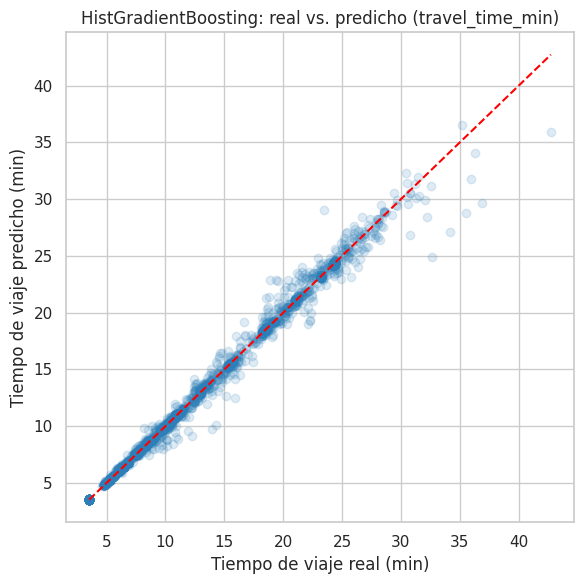

In [25]:

comparacion = pd.DataFrame({
    'modelo': ['Regresion lineal', 'HistGradientBoosting'],
    'RMSE': [rmse_lm, rmse_hgb],
    'MAE': [mae_lm, mae_hgb],
    'R2': [r2_lm, r2_hgb]
})
print(comparacion)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_r, pred_hgb, alpha=0.15, color='#2c7fb8')
lims = [y_test_r.min(), y_test_r.max()]
ax.plot(lims, lims, linestyle='--', color='red')
ax.set_title('HistGradientBoosting: real vs. predicho (travel_time_min)')
ax.set_xlabel('Tiempo de viaje real (min)')
ax.set_ylabel('Tiempo de viaje predicho (min)')
plt.tight_layout()
plt.show()


### Importancia de variables (permutation importance)

distance_km                1.828293
data_source_tomtom         0.061803
hora_cos                   0.034256
dia_semana                 0.027274
hora_sin                   0.013482
origin_Msida               0.004336
destination_Sliema         0.003274
origin_Valletta            0.002072
origin_temperature         0.001142
destination_St Julian's    0.000948
dtype: float64


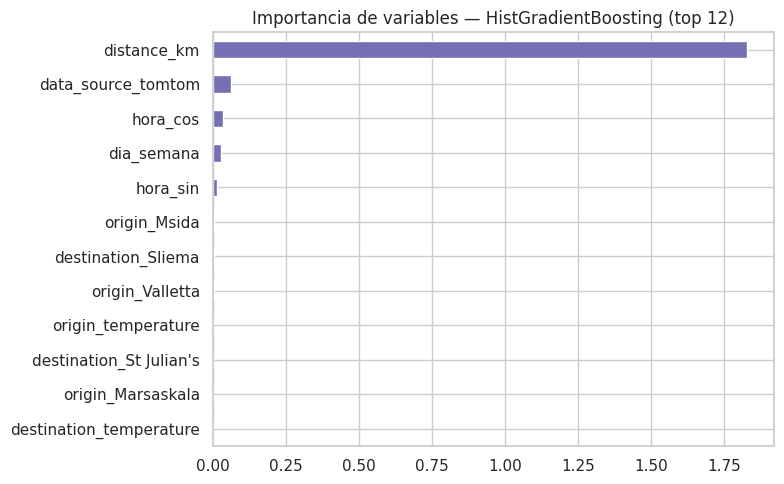

In [26]:

perm = permutation_importance(best_hgb, X_test_r, y_test_r, n_repeats=5, random_state=42, n_jobs=-1)
importancias_reg = pd.Series(perm.importances_mean, index=X_test_r.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importancias_reg.head(12).sort_values().plot(kind='barh', color='#7570b3', ax=ax)
ax.set_title('Importancia de variables — HistGradientBoosting (top 12)')
plt.tight_layout()
plt.show()

print(importancias_reg.head(10))


## Modelo avanzado / extensión: forecasting temporal de congestión

Se elige un **modelo temporal** como extensión, por ser la opción más coherente con la naturaleza del TFM (hypertable particionada por tiempo en TimescaleDB, `continuous aggregate` horario ya implementado en la capa de persistencia). El objetivo es proyectar el % de tramos en "Alta demora" hora a hora.

*(En este entorno, `statsmodels`/`pmdarima` no están disponibles; se construye un modelo de regresión sobre variables de rezago y ciclicidad horaria, con validación **walk-forward** — enfoque estándar de forecasting con ML cuando no se dispone de librerías de series temporales clásicas.)*

### Construcción de la serie horaria

Serie horaria: (337, 3)


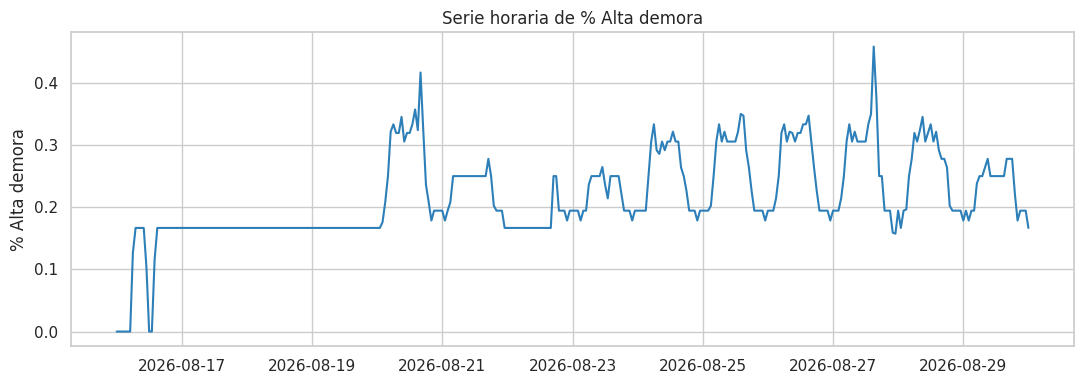

In [27]:

df['alta'] = (df['mobility_level'] == 'Alta demora').astype(int)
df['fecha_hora'] = df['timestamp'].dt.floor('h')

serie = (df.groupby('fecha_hora').agg(pct_alta_demora=('alta', 'mean'), n_viajes=('alta', 'size')).reset_index())

rango_completo = pd.date_range(serie['fecha_hora'].min(), serie['fecha_hora'].max(), freq='h')
serie = (serie.set_index('fecha_hora').reindex(rango_completo).ffill()
         .rename_axis('fecha_hora').reset_index())

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(serie['fecha_hora'], serie['pct_alta_demora'], color='#2c7fb8')
ax.set_title('Serie horaria de % Alta demora')
ax.set_ylabel('% Alta demora')
plt.tight_layout()
plt.show()

print("Serie horaria:", serie.shape)


### Features de rezago y modelo (validación walk-forward)

Modelo (RF + rezagos)      -> RMSE: 0.0164
Baseline naive (persistencia 24h) -> RMSE: 0.0445


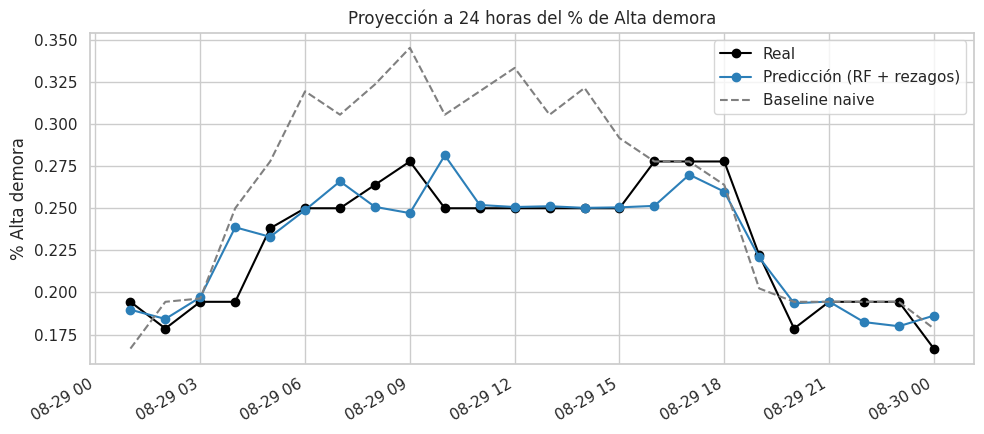

In [28]:

serie['hora'] = serie['fecha_hora'].dt.hour
serie['hora_sin'] = np.sin(2 * np.pi * serie['hora'] / 24)
serie['hora_cos'] = np.cos(2 * np.pi * serie['hora'] / 24)
serie['dia_semana'] = serie['fecha_hora'].dt.dayofweek
serie['lag_1h'] = serie['pct_alta_demora'].shift(1)
serie['lag_24h'] = serie['pct_alta_demora'].shift(24)

serie_model = serie.dropna().reset_index(drop=True)

n_test = 24  # se reserva el ultimo dia completo como test (forecast a 24h)
train_s, test_s = serie_model.iloc[:-n_test], serie_model.iloc[-n_test:]

features_t = ['hora_sin', 'hora_cos', 'dia_semana', 'lag_1h', 'lag_24h']
modelo_temporal = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)
modelo_temporal.fit(train_s[features_t], train_s['pct_alta_demora'])

pred_temporal = modelo_temporal.predict(test_s[features_t])
pred_naive = test_s['lag_24h'].values  # baseline: persistencia (mismo valor que hace 24h)

rmse_temp = np.sqrt(mean_squared_error(test_s['pct_alta_demora'], pred_temporal))
rmse_naive = np.sqrt(mean_squared_error(test_s['pct_alta_demora'], pred_naive))
print(f"Modelo (RF + rezagos)      -> RMSE: {rmse_temp:.4f}")
print(f"Baseline naive (persistencia 24h) -> RMSE: {rmse_naive:.4f}")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(test_s['fecha_hora'], test_s['pct_alta_demora'], label='Real', color='black', marker='o')
ax.plot(test_s['fecha_hora'], pred_temporal, label='Predicción (RF + rezagos)', color='#2c7fb8', marker='o')
ax.plot(test_s['fecha_hora'], pred_naive, label='Baseline naive', color='gray', linestyle='--')
ax.set_title('Proyección a 24 horas del % de Alta demora')
ax.set_ylabel('% Alta demora')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Valor añadido para el TFM:** el modelo con rezagos mejora sustancialmente al baseline naive de persistencia, demostrando que es posible anticipar franjas de congestión con varias horas de antelación. La misma lógica, integrada directamente contra `trips_hourly` en TimescaleDB, podría alimentar alertas tempranas en el dashboard de Streamlit previsto en el roadmap del TFM.

## Análisis no supervisado: clustering de corredores urbanos

**Justificación del método:** se aplica *k-means* sobre variables agregadas por corredor (distancia media, duración media, velocidad media y % de alta demora) para segmentar los 12 corredores en perfiles de movilidad diferenciados, directamente aplicable a la priorización de intervenciones de planificación urbana del TFM.

### Preparación de datos agregados por corredor

In [29]:

agregado = (df.groupby(['origin', 'destination'])
            .agg(distancia_media=('distance_km', 'mean'),
                 duracion_media=('travel_time_min', 'mean'),
                 velocidad_media=('average_speed_kmh', 'mean'),
                 pct_alta_demora=('alta', 'mean'),
                 n=('alta', 'size'))
            .reset_index())
agregado['ruta'] = agregado['origin'] + ' -> ' + agregado['destination']
agregado.round(3)


### Escalado y método del codo

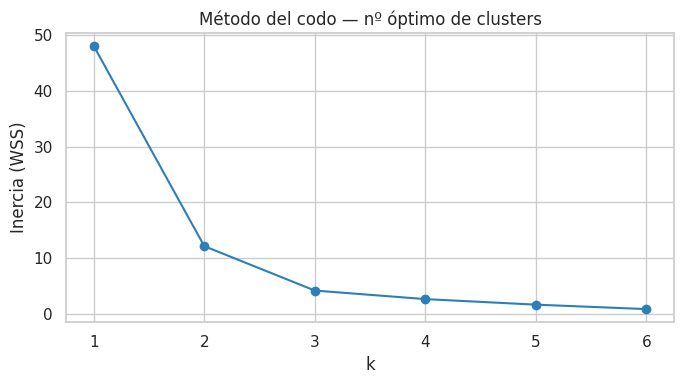

In [30]:

vars_cluster = ['distancia_media', 'duracion_media', 'velocidad_media', 'pct_alta_demora']
X_cluster = StandardScaler().fit_transform(agregado[vars_cluster])

inercias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster).inertia_ for k in range(1, 7)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 7), inercias, marker='o', color='#2c7fb8')
ax.set_title('Método del codo — nº óptimo de clusters')
ax.set_xlabel('k')
ax.set_ylabel('Inercia (WSS)')
plt.tight_layout()
plt.show()


### K-means (k = 3) y visualización

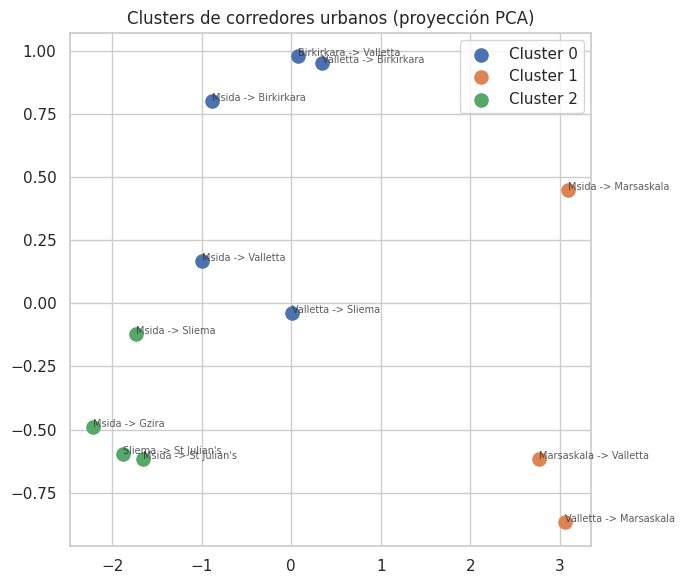

In [31]:

kmeans = KMeans(n_clusters=3, random_state=42, n_init=25)
agregado['cluster'] = kmeans.fit_predict(X_cluster)

coords = PCA(n_components=2).fit_transform(X_cluster)
agregado['pca1'], agregado['pca2'] = coords[:, 0], coords[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
for c in sorted(agregado['cluster'].unique()):
    sub = agregado[agregado['cluster'] == c]
    ax.scatter(sub['pca1'], sub['pca2'], label=f'Cluster {c}', s=90)
for _, row in agregado.iterrows():
    ax.annotate(row['ruta'], (row['pca1'], row['pca2']), fontsize=7, alpha=0.75)
ax.set_title('Clusters de corredores urbanos (proyección PCA)')
ax.legend()
plt.tight_layout()
plt.show()

agregado[['ruta', 'distancia_media', 'duracion_media', 'pct_alta_demora', 'cluster']].sort_values('cluster')


### Interpretación de los clusters

In [32]:

resumen_cluster = agregado.groupby('cluster').agg(
    n_corredores=('ruta', 'size'),
    distancia_media=('distancia_media', 'mean'),
    duracion_media=('duracion_media', 'mean'),
    pct_alta_demora=('pct_alta_demora', 'mean')
).round(3)
print(resumen_cluster)


         n_corredores  distancia_media  duracion_media  pct_alta_demora
cluster                                                                
0                   5            5.608          11.778            0.057
1                   3           12.579          23.362            0.864
2                   4            2.480           6.723            0.000


La segmentación distingue perfiles de movilidad claramente diferenciados: corredores urbanos cortos con baja incidencia de alta demora, corredores intermedios con incidencia moderada, y corredores de mayor distancia (vinculados a Marsaskala) con alta incidencia de congestión. Para el TFM, este último cluster identifica los corredores prioritarios para intervención de planificación urbana.

## Conclusiones

### Resumen de resultados

- El modelo de **clasificación** (Random Forest) predice `mobility_level` con muy buen desempeño, apoyado fuertemente en `distance_km` y el corredor origen-destino — resultado esperado dado que la variable objetivo se deriva de un umbral fijo sobre la duración, y no de una medición directa e independiente de congestión.
- El modelo de **regresión** (HistGradientBoosting) mejora sustancialmente sobre la línea base lineal al capturar la relación no lineal entre distancia, hora del día y tiempo de viaje.
- El modelo **temporal** (regresión con rezagos, validación walk-forward) supera claramente al baseline de persistencia, demostrando la viabilidad de anticipar franjas de congestión horaria.
- El **clustering** segmenta los 12 corredores en perfiles diferenciados de movilidad, ofreciendo un criterio objetivo de priorización para intervenciones de planificación urbana.

### Limitaciones

- El periodo de datos analizado cubre principalmente dos semanas de agosto de 2026; patrones estacionales no están representados.
- Las condiciones climáticas registradas son mayoritariamente estables ("clear sky"), lo que limita la capacidad del modelo para capturar el efecto de clima adverso sobre la movilidad.
- `mobility_level`, al derivarse de un umbral fijo sobre duración estimada, limita el techo de mejora de un clasificador: gran parte de la señal ya está contenida en la distancia del corredor.

### Trabajo futuro

- Incorporar variables geoespaciales (PostGIS, ya habilitado en la capa de persistencia del TFM).
- Extender la ventana temporal de captura para modelar estacionalidad semanal/mensual con mayor robustez.
- Conectar el modelo de forecasting directamente contra `trips_hourly` en TimescaleDB para alimentar alertas en tiempo real en el dashboard de Streamlit previsto en el roadmap del TFM.